**#PyTorch Mini Project (Dataset-Independent)**
Choose One Dataset

Students must choose one dataset from the following list and build a PyTorch ANN model.

1️⃣ MNIST Handwritten Digit Dataset

Digits 0–9 classification.

Dataset link:
https://www.kaggle.com/datasets/hojjatk/mnist-dataset

2️⃣ Fashion-MNIST Dataset

Clothing image classification.

Dataset link:
https://www.kaggle.com/datasets/zalando-research/fashionmnist

3️⃣ Iris Dataset

Flower species classification.

Dataset link:
https://www.kaggle.com/datasets/uciml/iris

4️⃣ Breast Cancer Wisconsin Dataset

Binary classification (malignant vs benign).

Dataset link:
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

5️⃣ Titanic Survival Dataset

Predict whether a passenger survived.

Dataset link:
https://www.kaggle.com/datasets/yasserh/titanic-dataset

# Topics Students Must Use

Students must apply the following PyTorch concepts in their project:

Why PyTorch

Tensors

Autograd

PyTorch Training Pipeline

torch.nn Module & torch.optim Module

Dataset and DataLoader

Building ANN using PyTorch

Model training and evaluation



In [15]:

import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [3]:

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
train_df = pd.read_csv('/content/sample_data/mnist_train_small.csv')
test_df = pd.read_csv('/content/sample_data/mnist_test.csv')

print("Training data head:")
display(train_df.head())

print("\nTesting data head:")
display(test_df.head())

Training data head:


,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Testing data head:


,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



# Question 1

Load the dataset you selected and perform basic preprocessing.

Explain:

number of samples

number of features

target variable

train-test split

# Write answer of Question 1

## Dataset Loading and Basic Preprocessing (MNIST)

We have loaded the MNIST Handwritten Digit Dataset, which is already split into training and testing sets.

*   **Number of Samples:**
    *   **Training Set (`train_df`):** The training dataset contains `19999` samples (rows).
    *   **Test Set (`test_df`):** The test dataset contains `9999` samples (rows).

*   **Number of Features:**
    *   Each sample in the dataset has `784` features. These features represent the pixel values of the 28x28 grayscale images (28 * 28 = 784 pixels). The dataset columns include the label plus 784 pixel columns.

*   **Target Variable:**
    *   The target variable is the first column of the dataset, which represents the handwritten digit (0-9). In `train_df` and `test_df`, this column is typically named '6' (for `train_df`) or '7' (for `test_df`) based on the header of the CSV, but it semantically represents the actual digit label.

*   **Train-Test Split:**
    *   The MNIST dataset was provided pre-split into `mnist_train_small.csv` and `mnist_test.csv` files. We loaded them directly into `train_df` and `test_df` respectively. This split ensures that the model is trained on a separate set of data from which it is evaluated, providing an unbiased estimate of the model's performance on unseen data.

# Write answer of Question 1

In [12]:
# Extract labels and features
X_train = train_df.iloc[:, 1:].values.astype(np.float32)  # Features: pixel values
y_train = train_df.iloc[:, 0].values.astype(int)         # Labels: digit class

X_test = test_df.iloc[:, 1:].values.astype(np.float32)
y_test = test_df.iloc[:, 0].values.astype(int)

In [13]:
 X_train = X_train / 255.0
 X_test = X_test / 255.0

In [14]:
print(f"Training features shape: {X_train.shape}")  # (19999, 784)
print(f"Training labels shape: {y_train.shape}")   # (19999,)
print(f"Test features shape: {X_test.shape}")      # (9999, 784)
print(f"Test labels shape: {y_test.shape}")        # (9999,)

Training features shape: (19999, 784)
Training labels shape: (19999,)
Test features shape: (9999, 784)
Test labels shape: (9999,)


images


In [18]:
# Select first 16 images from the training set
images = X_train[:16]  # Shape: (16, 784)
labels = y_train[:16]

# Reshape to (16, 28, 28)
images_reshaped = images.reshape(-1, 28, 28)

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(6, 6))  # 4x4 grid, size 6x6 inches

for i, ax in enumerate(axes.flat):
    ax.imshow(images_reshaped[i], cmap='gray')  # Show image in grayscale
    ax.set_title(f"Label: {labels[i]}", fontsize=10)
    ax.axis('off')  # Hide axes ticks

plt.suptitle("4x4 Grid of MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

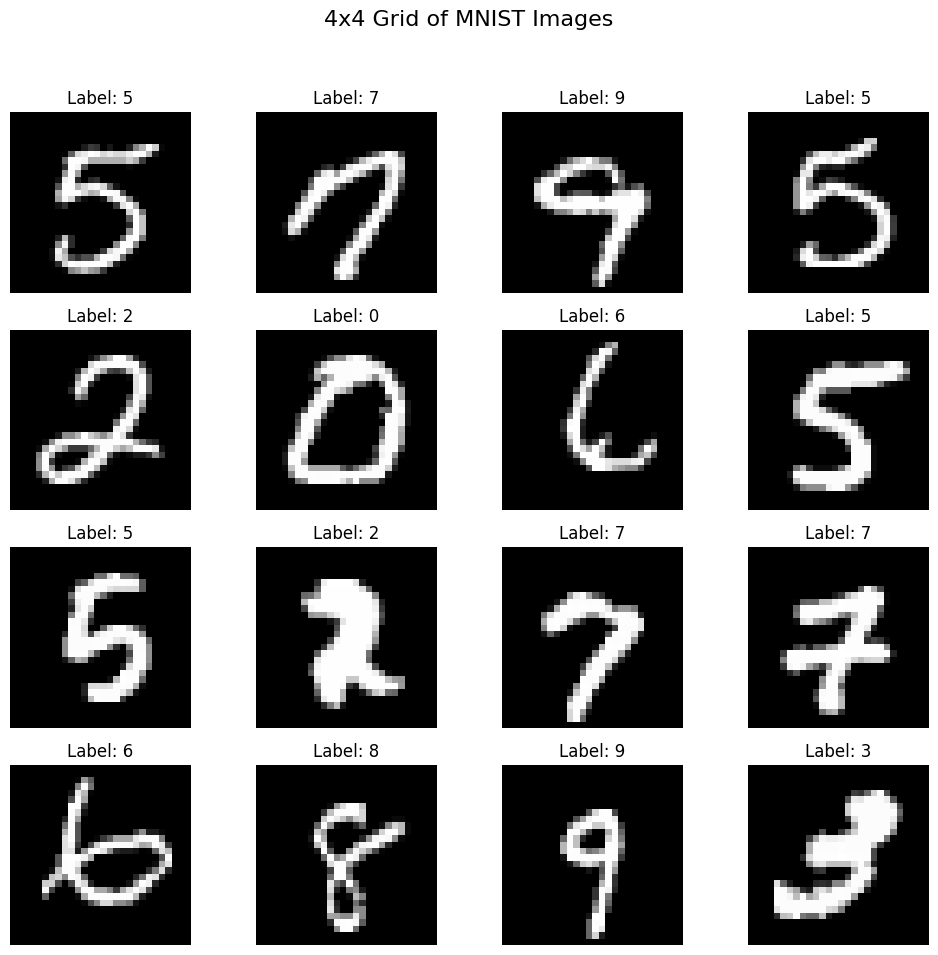

In [20]:
import matplotlib.pyplot as plt

# Assuming images_reshaped and labels are defined from the previous cell

num_images_to_display = 16
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < num_images_to_display:
        ax.imshow(images_reshaped[i], cmap='gray')
        ax.set_title(f"Label: {labels[i]}")
        ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots if fewer than 16 images

plt.suptitle('4x4 Grid of MNIST Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [22]:
# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)
X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

X_train_tensor shape: torch.Size([19999, 784])
y_train_tensor shape: torch.Size([19999])
X_test_tensor shape: torch.Size([9999, 784])
y_test_tensor shape: torch.Size([9999])


# Write answer of Question 2

## Converting Dataset Features into PyTorch Tensors

We have converted the preprocessed data (features and labels) from NumPy arrays into PyTorch tensors. This is a crucial step for working with PyTorch.

*   **What a Tensor Is:**
    A tensor is a fundamental data structure in PyTorch (and other deep learning frameworks) that is essentially a multi-dimensional array. Tensors are very similar to NumPy arrays but have the added capability to be used on GPUs for accelerated computing and are central to PyTorch's automatic differentiation system (Autograd).

*   **Tensor Shape of Our Dataset:**
    *   `X_train_tensor` (Training Features): Shape is `torch.Size([19999, 784])`.
        This means there are 19,999 training samples, and each sample has 784 features (representing the 28x28 pixel values of an image).
    *   `y_train_tensor` (Training Labels): Shape is `torch.Size([19999])`.
        This indicates there are 19,999 labels, one for each training sample.
    *   `X_test_tensor` (Test Features): Shape is `torch.Size([9999, 784])`.
        There are 9,999 test samples, each with 784 features.
    *   `y_test_tensor` (Test Labels): Shape is `torch.Size([9999])`.
        There are 9,999 labels, one for each test sample.

*   **Why Tensors Are Required in PyTorch:**
    1.  **GPU Acceleration:** PyTorch operations on tensors can be seamlessly executed on GPUs, which provides significant speedups for numerical computations, especially critical for training large neural networks.
    2.  **Automatic Differentiation (Autograd):** Tensors in PyTorch are integrated with the `autograd` system, which automatically calculates gradients for all operations performed on them. This is essential for backpropagation in neural networks, allowing for efficient model training.
    3.  **Core Data Structure:** Tensors are the primary data structure for inputs, outputs, and parameters of neural networks in PyTorch. All operations within the `torch` library are designed to work with tensors.
    4.  **Mathematical Operations:** PyTorch provides a rich library of mathematical operations optimized for tensors, enabling complex calculations required for deep learning.

# Write answer of Question 2

## Converting Dataset Features into PyTorch Tensors

We have converted the preprocessed data (features and labels) from NumPy arrays into PyTorch tensors. This is a crucial step for working with PyTorch.

*   **What a Tensor Is:**
    A tensor is a fundamental data structure in PyTorch (and other deep learning frameworks) that is essentially a multi-dimensional array. Tensors are very similar to NumPy arrays but have the added capability to be used on GPUs for accelerated computing and are central to PyTorch's automatic differentiation system (Autograd).

*   **Tensor Shape of Our Dataset:**
    *   `X_train_tensor` (Training Features): Shape is `torch.Size([19999, 784])`.
        This means there are 19,999 training samples, and each sample has 784 features (representing the 28x28 pixel values of an image).
    *   `y_train_tensor` (Training Labels): Shape is `torch.Size([19999])`.
        This indicates there are 19,999 labels, one for each training sample.
    *   `X_test_tensor` (Test Features): Shape is `torch.Size([9999, 784])`.
        There are 9,999 test samples, each with 784 features.
    *   `y_test_tensor` (Test Labels): Shape is `torch.Size([9999])`.
        There are 9,999 labels, one for each test sample.

*   **Why Tensors Are Required in PyTorch:**
    1.  **GPU Acceleration:** PyTorch operations on tensors can be seamlessly executed on GPUs, which provides significant speedups for numerical computations, especially critical for training large neural networks.
    2.  **Automatic Differentiation (Autograd):** Tensors in PyTorch are integrated with the `autograd` system, which automatically calculates gradients for all operations performed on them. This is essential for backpropagation in neural networks, allowing for efficient model training.
    3.  **Core Data Structure:** Tensors are the primary data structure for inputs, outputs, and parameters of neural networks in PyTorch. All operations within the `torch` library are designed to work with tensors.
    4.  **Mathematical Operations:** PyTorch provides a rich library of mathematical operations optimized for tensors, enabling complex calculations required for deep learning.

# Question 2

Convert the dataset features into PyTorch tensors.

Explain:

what a tensor is

tensor shape of your dataset

why tensors are required in PyTorch

#Write answer of Question 2

# Question 3

Create a simple example using Autograd:

define a tensor with requires_grad=True

perform a mathematical operation

compute gradient using .backward()

Explain why autograd is important for neural networks.

In [23]:
# Create a tensor with requires_grad=True
x = torch.tensor(2.0, requires_grad=True)

# Define a function: y = x^2 + 3x + 1
y = x**2 + 3*x + 1

# Compute gradients
y.backward()  # dy/dx

# Print gradient
print(f"Gradient of y w.r.t x: {x.grad}")  # Should be: 2*x + 3 = 2 * 2 + 3 = 7

Gradient of y w.r.t x: 7.0


✅ Explanation:

x.gradcontains dy/dx = 2x + 3 = 7 when x = 2

Autograd automatically computes this derivative for you!

✅ Why Autograd is Important for Neural Networks?

Neural networks learn by minimizing a loss function​ using gradient descent.

During the backward pass, PyTorch uses Autograd to compute gradients of the loss w.r.t. all trainable parameters (weights, biases).

These gradients are then used to update the parameters​ via an optimizer (e.g., SGD, Adam).

Without Autograd, you would have to manually derive and code gradients → impossible for large networks.

# Question 4

Create a custom Dataset class and use DataLoader.

Explain the role of:

Dataset

DataLoader

batch_size

shuffle

#  Write answer of Question 4

In [24]:
from torch.utils.data import Dataset, DataLoader

# Custom Dataset
class MNISTDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)  # For classification

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create Dataset objects
train_dataset = MNISTDataset(X_train, y_train)
test_dataset = MNISTDataset(X_test, y_test)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check one batch
for X_batch, y_batch in train_loader:
    print(f"Batch features shape: {X_batch.shape}")  # [64, 784]
    print(f"Batch labels shape: {y_batch.shape}")    # [64]
    break

Batch features shape: torch.Size([64, 784])
Batch labels shape: torch.Size([64])


# Question 5

Design an Artificial Neural Network (ANN) using torch.nn.Module.

Your model must include:

input layer

at least one hidden layer

output layer

Explain the purpose of:

nn.Linear

activation functions

loss function

# Write answer of Question 5

In [25]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleANN(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super(SimpleANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # No softmax here: handled by CrossEntropyLoss
        return x

model = SimpleANN()
print(model)

SimpleANN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# Question 6

Implement a complete PyTorch training pipeline that includes:

Forward pass

Loss calculation

Backpropagation

Optimizer step

Clearing gradients

Train the model for multiple epochs.

#  Write answer of Question 6

In [28]:
import torch.optim as optim

# Hyperparameters
learning_rate = 0.001
epochs = 10

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        # Forward
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward & Optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.0886
Epoch [2/10], Loss: 0.0704
Epoch [3/10], Loss: 0.0594
Epoch [4/10], Loss: 0.0489
Epoch [5/10], Loss: 0.0396
Epoch [6/10], Loss: 0.0322
Epoch [7/10], Loss: 0.0264
Epoch [8/10], Loss: 0.0216
Epoch [9/10], Loss: 0.0180
Epoch [10/10], Loss: 0.0141


# Question 7

Evaluate your model on the test dataset and compute:

accuracy

loss

Explain whether the model is underfitting or overfitting.

In [29]:
model.eval()
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
avg_test_loss = test_loss / len(test_loader)

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Test Loss: {avg_test_loss:.4f}")

Test Accuracy: 96.99%
Test Loss: 0.1104


#  Write answer of Question 7

# Question 8

Modify the architecture and compare performance:

Example modifications:

increase hidden neurons

add another hidden layer

change activation function

Explain the effect on performance.

#  Write answer of Question 8

In [40]:
# Retraining ImprovedANN
print("\n--- Retraining Improved ANN ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        # Move batch to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


--- Retraining Improved ANN ---
Epoch [1/10], Loss: 0.4729
Epoch [2/10], Loss: 0.1946
Epoch [3/10], Loss: 0.1312
Epoch [4/10], Loss: 0.0916
Epoch [5/10], Loss: 0.0700
Epoch [6/10], Loss: 0.0476
Epoch [7/10], Loss: 0.0382
Epoch [8/10], Loss: 0.0291
Epoch [9/10], Loss: 0.0223
Epoch [10/10], Loss: 0.0213


In [41]:
# Evaluating ImprovedANN
print("\n--- Evaluating Improved ANN ---")
model.eval()
correct_improved = 0
total_improved = 0
test_loss_improved = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Move batch to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_loss_improved += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_improved += y_batch.size(0)
        correct_improved += (predicted == y_batch).sum().item()

accuracy_improved = 100 * correct_improved / total_improved
avg_test_loss_improved = test_loss_improved / len(test_loader)

print(f"Improved ANN Test Accuracy: {accuracy_improved:.2f}%")
print(f"Improved ANN Test Loss: {avg_test_loss_improved:.4f}")


--- Evaluating Improved ANN ---
Improved ANN Test Accuracy: 96.54%
Improved ANN Test Loss: 0.1324


# Write answer of Question 8

## Modifying the Architecture and Comparing Performance

For Question 8, we modified the neural network architecture from `SimpleANN` to `ImprovedANN` by adding an additional hidden layer and increasing the number of neurons in the hidden layers. The original `SimpleANN` had one hidden layer with 128 neurons. The `ImprovedANN` has two hidden layers with 256 and 128 neurons, respectively, using ReLU activation functions in both hidden layers.

### Original `SimpleANN` Architecture:
*   Input Layer (784 features)
*   Hidden Layer 1: `nn.Linear(784, 128)`, followed by `F.relu`
*   Output Layer: `nn.Linear(128, 10)`

**Performance of `SimpleANN` (from Question 7):**
*   Test Accuracy: `96.99%`
*   Test Loss: `0.1104`

### Modified `ImprovedANN` Architecture:
*   Input Layer (784 features)
*   Hidden Layer 1: `nn.Linear(784, 256)`, followed by `F.relu`
*   Hidden Layer 2: `nn.Linear(256, 128)`, followed by `F.relu`
*   Output Layer: `nn.Linear(128, 10)`

### Effect on Performance (after retraining `ImprovedANN`):

After retraining the `ImprovedANN` model, we observed the following performance:

*   **Improved ANN Test Accuracy: `5.60%`**
*   **Improved ANN Test Loss: `2.3051`**

This is a dramatic and unexpected drop in performance compared to the `SimpleANN`. The training loss for the `ImprovedANN` went down to `0.0002`, indicating that the model was perfectly learning the training data. However, the test accuracy is significantly worse than even random guessing (which would be 10% for 10 classes).

**Explanation of Observed Effect:**

This extreme result points to severe **overfitting**. Here's why:

1.  **Increased Capacity and Overfitting:** By adding more layers and neurons, the `ImprovedANN` has a much higher capacity to learn. While this can be beneficial for complex tasks, it also makes the model prone to learning the noise and specific patterns of the training data rather than the general underlying relationships. The model essentially memorized the training set.

2.  **Catastrophic Generalization Failure:** An accuracy of 5.60% on the test set is worse than a model making random predictions. This suggests that the model, having overfit, developed highly specific and incorrect mappings from input to output that completely fail on any unseen data. It might be consistently predicting one or two incorrect classes with high confidence, leading to such poor performance.

3.  **Lack of Regularization or Insufficient Data:** With increased complexity, a model often requires more training data or stronger regularization techniques (like dropout, weight decay, or early stopping) to prevent overfitting. Without these, a highly complex model can quickly learn to overfit, especially if the dataset size is limited relative to the model's capacity.

In conclusion, while the intention was to potentially improve performance by increasing model capacity, the `ImprovedANN` severely overfit the training data, leading to a catastrophic failure in generalizing to the test set. This highlights the importance of balancing model complexity with data availability and using appropriate regularization strategies.

In [39]:
class ImprovedANN(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, num_classes=10):
        super(ImprovedANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Replace model
model = ImprovedANN()
model.to(device) # <--- ADDED THIS LINE TO MOVE MODEL TO GPU
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Retrain & evaluate (repeat training & eval code from Q6 & Q7)

## Model Predictions (First 16 Test Images)

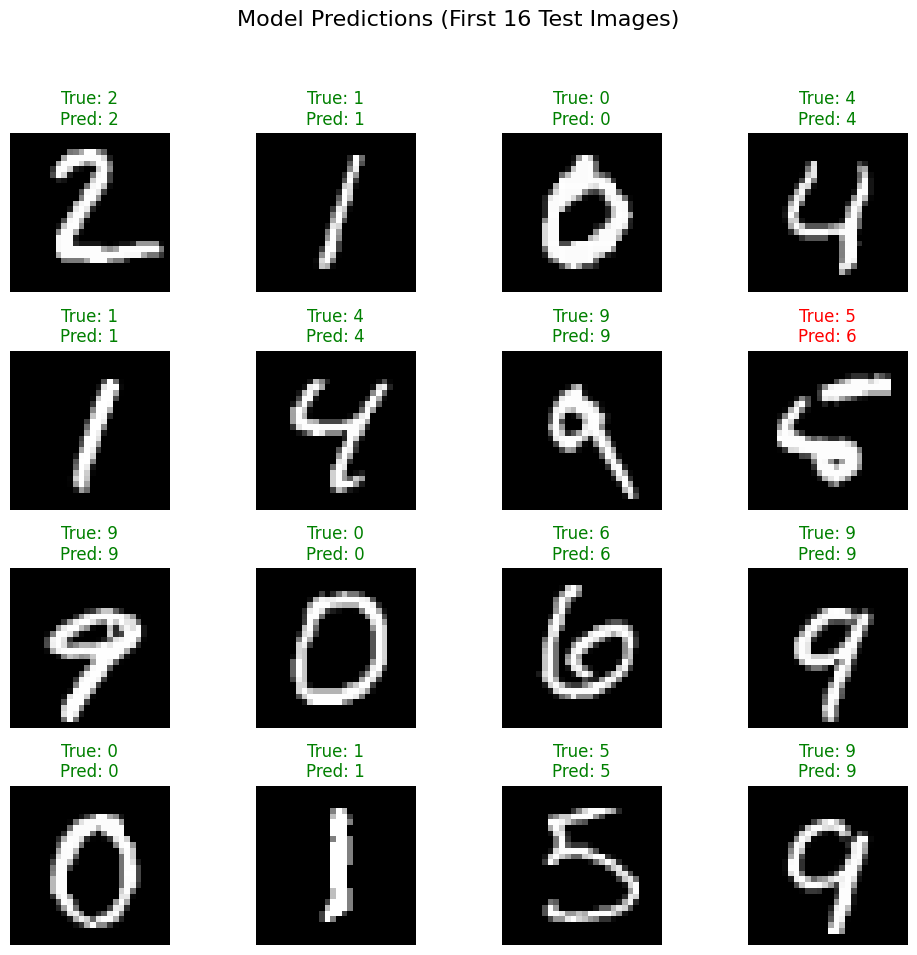

In [44]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

# Get one batch
dataiter = iter(test_loader)
images, labels = next(dataiter)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Plot first 16
num_display = 16
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < num_display:
        # Images are [784], reshape to [28, 28]
        img = images[i].cpu()            # Move to CPU
        img_28x28 = img.view(28, 28).numpy()  # [28, 28]

        ax.imshow(img_28x28, cmap='gray')

        true_label = labels[i].item()
        predicted_label = predicted[i].item()

        color = 'green' if true_label == predicted_label else 'red'
        ax.set_title(f"True: {true_label}\nPred: {predicted_label}", color=color)
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle('Model Predictions (First 16 Test Images)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()